# 1D Vlasov–Ampere system

$$
\frac{\partial f}{\partial t} + \upsilon \frac{\partial f}{\partial x}
- E(t,x) \frac{\partial f}{\partial \upsilon} = 0
$$

$$
\frac{\partial E}{\partial t} = - J = \int f\upsilon \; d\upsilon
$$

## Algorithm 

- For each $j$ compute discrete Fourier transform in $x$ of $f^n(x_i,\upsilon_j)$ yielding $f_k^n(\upsilon_j)$, 

- For $ k \neq 0 $

    - Compute 
    
    $$f^{n+1}_k(\upsilon_j) = e^{−2i\pi k \upsilon
    \Delta t/L} f_n^k(\upsilon_j),$$
    
    - Compute 
    
    $$\rho_k^{n+1} = \Delta \upsilon \sum_j􏰄 f^{n+1}_k(\upsilon_j),$$
    
    - Compute
    
    $$E^{n+1}_k = \rho^{n+1}_k L/(2i\pi k \epsilon_0),$$
    
- For $k = 0$ do nothing: 

$$f_{n+1}(\upsilon_j) = f^n_k(\upsilon_j), E^{n+1}_k = E^n_k$$.

- Perform inverse discrete Fourier transform of $E^{n+1}_k$ and for each $j$ of $f^{n+1}_k (\upsilon_j)$.

## Import dependencies

In [1]:
using ProgressMeter, FFTW, Plots, LinearAlgebra
using BenchmarkTools, Statistics

## Mesh data structure

In [2]:
"""
    UniformMesh(start, stop, length)

    1D uniform mesh data.
"""
struct UniformMesh

   start    :: Float64
   stop     :: Float64
   length   :: Int64
   step     :: Float64
   points   :: Vector{Float64}

   function UniformMesh(start, stop, length::Int; endpoint=true)

       points = range(start, stop=stop, length=length+1)[1:end-1]
       step = (stop - start) / length

       new( start, stop, length, step, points)

   end

end

UniformMesh

## Function to compute the charge density

In [3]:
"""

    compute_rho( mesh, f)

    Compute charge density

    ρ(x,t) = ∫ f(x,v,t) dv

    return ρ - ρ̄ 

"""
function compute_rho(meshv::UniformMesh, f)

   dv  = meshv.step
   ρ = dv .* vec(sum(real(f), dims=2))
   ρ .- mean(ρ)
   
end

compute_rho

## Function to compute the electric field

In [4]:
"""
compute electric field from ρ
"""
function compute_e(mesh::UniformMesh, ρ)

   n = mesh.length
   k =  2π / (mesh.stop - mesh.start)
   modes  = zeros(Float64, n)
   modes .= k * vcat(0:n÷2-1,-n÷2:-1)
   modes[1] = 1.0
   ρ̂ = fft(ρ)./modes
   vec(real(ifft(-1im .* ρ̂)))

end

compute_e

## Structure to store data for advection

In [5]:
"""

    advection! = AmpereAdvection( mesh ) 

    ∂f/∂t − v ∂f/∂x  = 0
    ∂E/∂t = −J = ∫ fv dv
    ∂f/∂t − E(x) ∂f/∂v  = 0

"""
struct AmpereAdvection 
    
    mesh :: UniformMesh
    kx   :: Vector{Float64}

    function AmpereAdvection( mesh )
        
        nx  = mesh.length
        dx  = mesh.step
        Lx  = mesh.stop - mesh.start
        kx  = zeros(Float64, nx)
        kx .= 2π/Lx .* [0:nx÷2-1;-nx÷2:-1]
        new( mesh, kx)
      
    end

end

AmpereAdvection

## Implement advection function in velocity


In [6]:
"""
    Advection function along v

```math
\\frac{df}{dt} = e \\frac{df}{dv}
```

"""
function (adv :: AmpereAdvection)( fᵗ  :: Array{ComplexF64,2}, 
                                   e   :: Vector{ComplexF64}, 
                                   dt  :: Float64 )
    fft!(fᵗ, 1)
    fᵗ .= fᵗ .* exp.(-1im * dt * adv.kx * transpose(e))
    ifft!(fᵗ, 1)

end

AmpereAdvection

## Implement advection function in space 

In [7]:
"""
    Advection function along x and e computation

```math
\\frac{df}{dt} = v \\frac{df}{dx}
```
```math
\\frac{\\partial E}{\\partial t} = \\int fv \\; dv
```

"""
function (adv :: AmpereAdvection)( f   :: Array{ComplexF64,2}, 
                                   e   :: Vector{ComplexF64}, 
                                   v   :: Vector{Float64}, 
                                   dt  :: Float64 )
    
    ev = exp.(-1im*dt * adv.kx * transpose(v))    
    
    fft!(f,1)
    f .= f .* ev
    dv = v[2]-v[1]
    ρ = dv * vec(sum(f,dims=2))  
    for i in 2:length(e)
        e[i] = -1im * ρ[i] ./ adv.kx[i]
    end
    e[1] = 0.0
    ifft!(f,1)
    ifft!(e)
    e .= real(e)
end

AmpereAdvection

## Initialize the distribution function

In [8]:
"""
Landau damping initialisation function

[Wikipedia](https://en.wikipedia.org/wiki/Landau_damping)

```math
f(x,v) = \\frac{1}{\\sqrt{2\\pi}}(1+ ϵ \\cdot cos(kₓ x)) e^{-v^2/2}
```

"""
function landau( ϵ, kx, x, v )
    
    (1.0.+ϵ*cos.(kx*x))/sqrt(2π) .* transpose(exp.(-0.5*v.*v))
    
end

landau

In [9]:
?landau

search: landau tand rand plan_dct randn nand



Landau damping initialisation function

[Wikipedia](https://en.wikipedia.org/wiki/Landau_damping)

$$
f(x,v) = \frac{1}{\sqrt{2\pi}}(1+ ϵ \cdot cos(kₓ x)) e^{-v^2/2}
$$


## Simulation function

In [10]:
function vlasov_ampere( nx, nv, xmin, xmax, vmin, vmax , tf, nt)

    meshx = UniformMesh(xmin, xmax, nx)
    meshv = UniformMesh(vmin, vmax, nv)
            
    # Initialize distribution function
    x = meshx.points
    v = meshv.points
    ϵ, kx = 0.001, 0.5
    
    # Allocate arrays for distribution function and its transposed
    f = zeros(Complex{Float64},(nx,nv))
    fᵀ= zeros(Complex{Float64},(nv,nx))
    
    f .= landau( ϵ, kx, x, v)
    
    transpose!(fᵀ,f)
    
    ρ  = compute_rho(meshv, f)
    e  = zeros(ComplexF64, nx)
    e .= compute_e(meshx, ρ)
    
    nrj = Float64[]
    
    dt = tf / nt
    
    advection_x! = AmpereAdvection( meshx )
    advection_v! = AmpereAdvection( meshv )
            
    @showprogress 1 for i in 1:nt
        
        advection_v!(fᵀ, e,  0.5dt)
        
        transpose!(f,fᵀ)
        
        advection_x!( f, e, v, dt)
        
        push!(nrj, log(sqrt((sum(e.^2))*meshx.step)))
        
        transpose!(fᵀ,f)
        
        advection_v!(fᵀ, e,  0.5dt)
        
    end
    real(f), nrj
end

vlasov_ampere (generic function with 1 method)

## Run simulation

Progress: 100%|█████████████████████████████████████████| Time: 0:00:05


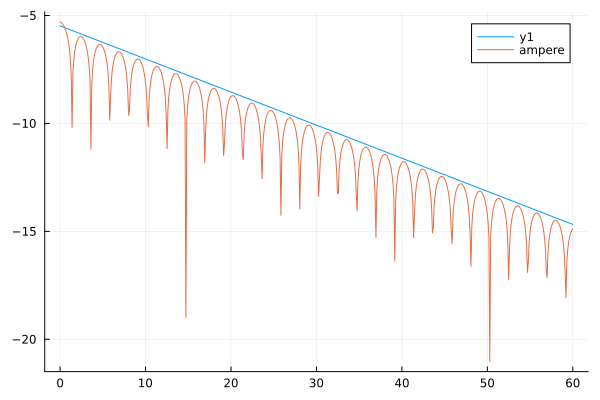

In [12]:
nx, nv = 256, 256
xmin, xmax =  0., 4*π
vmin, vmax = -6., 6.
tf = 60
nt = 600
t =  range(0,stop=tf,length=nt)
plot(t, -0.1533*t.-5.48)
f, nrj = vlasov_ampere(nx, nv, xmin, xmax, vmin, vmax, tf, nt)
plot!(t, nrj , label="ampere" )